In [14]:
import numpy as np
import matplotlib.pyplot as plt

## Άσκηση - Σειρά Fourier Διακριτού Χρόνου

Ας προσπαθήσουμε να προσομοιώσουμε τη σειρά Fourier διακριτού χρόνου σε διάφορα σήματα στην ````Python````. Ξέρουμε στη θεωρία, λοιπόν, πώς να αναλύουμε ένα $\textit{περιοδικό}$ σήμα διακριτού χρόνου σε σειρά Fourier. Σε αντίθεση όμως με τον μετασχ. Fourier διακριτού χρόνου, ο οποίος είναι $\textit{συνεχής}$ συνάρτηση του $\omega$ και άρα ορίζεται σε άπειρα σημεία, η σειρά Fourier διακριτού χρόνου ορίζεται μόνο για περιοδικά σήματα και έχει $\textit{πεπερασμένο}$ πλήθος συντελεστών - ακριβώς $N$, όσο και η περίοδος του σήματος. Αυτό είναι πολύ βολικό για την ````Python````: δεν χρειάζεται καμία προσέγγιση ή δειγματοληψία της συχνότητας, όπως αναγκαστήκαμε να κάνουμε στον μετασχ. Fourier: τη σειρά την υλοποιούμε $\textit{ακριβώς}$! 😃 

Η άσκηση αυτή απαιτεί την κατανόησή των όσων αναφέρονται, καθώς ο κώδικας που καλείστε να γράψετε είναι ελάχιστος.

Ας θυμηθούμε τους ορισμούς. Για ένα περιοδικό σήμα $x[n]$ με περίοδο $N_0$, οι συντελεστές της σειράς Fourier δίνονται από την $\textit{εξίσωση ανάλυσης}$:

\begin{equation}
a_k = \frac{1}{N_0}\sum_{n=<N_0>}x[n]e^{-j\frac{2\pi}{N_0}kn}
\end{equation}

ενώ το σήμα ανακατασκευάζεται από τους συντελεστές μέσω της $\textit{εξίσωσης σύνθεσης}$:

\begin{equation}
x[n] = \sum_{k=<N_0>}a_k e^{j\frac{2\pi}{N_0}kn}
\end{equation}

με τον συμβολισμό $<N_0>$ να δηλώνει ότι αθροίζουμε $N_0$ συνεχόμενα δείγματα, δηλ. πάνω σε $\textit{μία}$ περίοδο (π.χ. από $n=0$ ως $N_0-1$). Η ποσότητα $\omega_0 = \frac{2\pi}{N_0}$ είναι η **θεμελιώδης συχνότητα**.

Δύο πράγματα αξίζει να τα προσέξετε από τώρα: πρώτον, το άθροισμα είναι $\textit{πεπερασμένο}$ (έχει ακριβώς $N_0$ όρους). Δεύτερον, οι συντελεστές $a_k$ είναι κι αυτοί $\textit{περιοδικοί}$ ως προς $k$ με περίοδο $N_0$, δηλ. $a_{k+N} = a_k$. Άρα υπάρχουν ακριβώς $N_0$ διακριτοί συντελεστές, και τους υπολογίζουμε όλους χωρίς καμία προσέγγιση.

Δείτε έναν απλό και διαισθητικό τρόπο να υλοποιήσουμε την $\textit{ανάλυση}$ (τον υπολογισμό των συντελεστών $a_k$), με τον παρακάτω κώδικα, για ένα πολύ γνωστό σας σήμα, το $x[n] = \cos\left(\frac{2\pi k_0}{N}n\right)$:

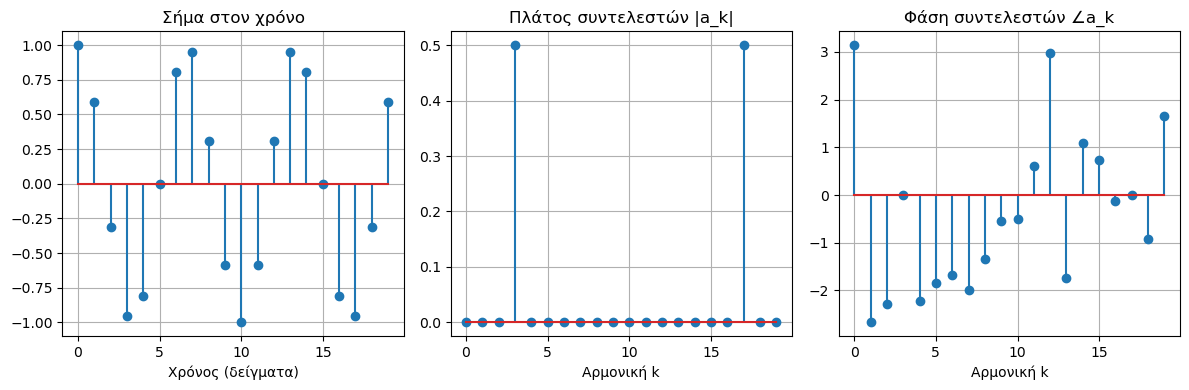

In [ ]:
# Παράμετροι
N0 = 20                       # Περίοδος του σήματος
k0 = 3                        # Αρμονική του συνημιτόνου
n = np.arange(N0)             # Διάνυσμα διακριτού χρόνου: 0..N-1 (μία περίοδος)
x = np.cos(2*np.pi*k0*n/N0)   # x[n] = cos(2π k0 n / N)

a = np.zeros(N0, dtype=np.complex128)   # (κενό) διάνυσμα συντελεστών Fourier

# Βρόχοι - Άθροιση της εξίσωσης ανάλυσης για κάθε συντελεστή a_k
for k in range(N0):
    for i in range(N0):
        a[k] += x[i] * np.exp(-1j * (2*np.pi/N0) * k * n[i])
    a[k] /= N0

# Σχεδίαση σήματος, πλάτους και φάσης των συντελεστών
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.stem(n, x)
plt.grid()
plt.title('Σήμα στον χρόνο')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 3, 2)
plt.stem(np.arange(N0), np.abs(a))
plt.grid()
plt.title('Πλάτος συντελεστών |a_k|')
plt.xlabel('Αρμονική k')

plt.subplot(1, 3, 3)
plt.stem(np.arange(N0), np.angle(a))
plt.grid()
plt.title('Φάση συντελεστών ∠a_k')
plt.xlabel('Αρμονική k')

plt.tight_layout()

Ο τρόπος αυτός είναι αρκετά διαισθητικός αλλά όχι ο βέλτιστος δυνατός - για την ακρίβεια, είναι ιδιαίτερα αργός σε περιβάλλοντα όπως η ````Python````, λόγω των $\textit{δύο}$ εμφωλευμένων βρόχων επανάληψης.

Καλείστε να συμπληρώσετε την παρακάτω δοσμένη συνάρτηση ````myDTFS```` η οποία υπολογίζει τους συντελεστές της σειράς Fourier διακριτού χρόνου με διαφορετικό τρόπο από τον παραπάνω, και την οποία θα χρησιμοποιήσετε παρακάτω.

In [17]:
def myDTFS(x):
    """
    Υπολογίζει τους συντελεστές της σειράς Fourier διακριτού χρόνου
    ενός περιοδικού σήματος, δοθείσης μίας περιόδου του.

    Ορίσματα:
        x : 1D τύπου πίνακα, τα N δείγματα μίας περιόδου του σήματος

    Επιστρέφει:
        a : 1D μιγαδικό np.ndarray μήκους N (οι συντελεστές a_k, k=0..N0-1)
    """
    x = np.asarray(x, dtype=np.complex128)
    N0 = len(x)                 # Περίοδος = πλήθος δειγμάτων

    n = np.arange(N0)           # Δείκτες χρόνου: 0..N0-1
    k = np.arange(N0)           # Δείκτες αρμονικών: 0..N0-1

    # Πίνακας E: διάσταση (N0, N0), με E[n, k] = exp(-j (2π/N0) k n)
    E = np.exp(-1j * (2*np.pi/N0) * np.outer(n, k))

    # Συντελεστές - χρήση των x και E
    a = (1/N0) * (x @ E)        # Χρήση του τελεστή @

    return a

με $x$ το διάνυσμα που αντιπροσωπεύει μία περίοδο του περιοδικού σήματος διακριτού χρόνου.

### Επεξήγηση:

Το διάνυσμα $a$ θα περιέχει τους $N_0$ συντελεστές της σειράς Fourier. Η υλοποίησή της γίνεται πιο γρήγορα και αποδοτικά με χρήση πινάκων, γλιτώνοντας τους δύο βρόχους. Για το τελευταίο, προσέξτε ότι το διάνυσμα των συντελεστών $a$ μπορεί να γραφεί ως το γινόμενο

\begin{equation}
a = \frac{1}{N_0}x^T E
\end{equation}

των πινάκων

\begin{equation}
x_{N_0\times 1} = \begin{bmatrix}
x[0] \\
x[1] \\
\vdots \\
x[N_0-1]
\end{bmatrix}
\end{equation}

που περιέχει τις τιμές μίας περιόδου του σήματος διακριτού χρόνου και

\begin{equation}
E_{N_0 \times N_0} = \begin{bmatrix}
\vert & \vert & \vert & \vert \\
\vert & \vert & \vert & \vert \\
e^{-j\frac{2\pi}{N_0}\cdot 0 \cdot n} & e^{-j\frac{2\pi}{N_0}\cdot 1 \cdot n} & \cdots & e^{-j\frac{2\pi}{N_0}(N_0-1) n} \\
\vert & \vert & \vert & \vert \\
\vert & \vert & \vert & \vert \\
\end{bmatrix}
\end{equation}

τον περίφημο πίνακα Fourier, με $n = 0, 1, \cdots, N_0-1$. Το σύμβολο $^T$ δηλώνει το ανάστροφο διάνυσμα.

Παρατηρήστε ότι σε κάθε στήλη $k$ του πίνακα $E$ υπάρχει ένα μιγαδικό εκθετικό σήμα $\textit{συγκεκριμένης}$ αρμονικής συχνότητας $\frac{2\pi}{N_0}k$, για τις χρονικές τιμές $n = 0,\cdots,N_0-1$. Έτσι, θα έχουμε $N_0$ στήλες, όσες και οι διαφορετικές αρμονικές. Επίσης, θα έχουμε $N_0$ γραμμές, αφού η μεταβλητή $n$ δηλώνει τον χρόνο και έχουμε $N_0$ τέτοιες τιμές. Τέλος, παρατηρήστε ότι το γινόμενο $\frac{1}{N_0}x^T E$ θα πρέπει να σας δώσει ένα μιγαδικό διάνυσμα διάστασης $1\times N_0$, σύμφωνα με τους κανόνες της Γραμμικής Άλγεβρας. Κάθε τιμή του διανύσματος αυτού θα είναι ένας συντελεστής $a_k$ της σειράς Fourier!

---

Όταν γράψετε σωστά τη συνάρτηση, εκτελέστε τον κώδικα που ακολουθεί για να την ελέγξετε. Ο κώδικας υπολογίζει τους συντελεστές του σήματος

\begin{equation}
x[n] = \cos\left(\frac{2\pi k_0}{N}n\right)
\end{equation}

του οποίου γνωρίζετε τη σειρά Fourier από τη θεωρία: όλοι οι συντελεστές είναι μηδέν, εκτός από τους $a_{k_0} = a_{N_0-k_0} = \frac{1}{2}$.

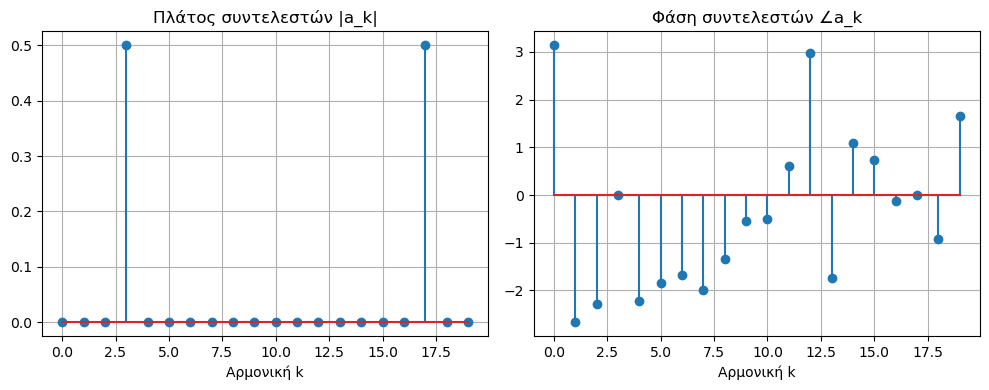

In [18]:
# Έλεγχος της myDTFS...
N0 = 20                        # Περίοδος
k0 = 3                        # Αρμονική
n = np.arange(N0)              # Διάνυσμα χρόνου 0..N-1
x = np.cos(2*np.pi*k0*n/N0)    # Σήμα: cos(2π k0 n / N)

a = myDTFS(x)                 # Κλήση της συνάρτησης

# Σχεδίαση πλάτους και φάσης των συντελεστών
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(np.arange(N0), np.abs(a))
plt.grid(True)
plt.title('Πλάτος συντελεστών |a_k|')
plt.xlabel('Αρμονική k')

plt.subplot(1, 2, 2)
plt.stem(np.arange(N0), np.angle(a))
plt.grid(True)
plt.title('Φάση συντελεστών ∠a_k')
plt.xlabel('Αρμονική k')

plt.tight_layout()

Αν όλα πάνε καλά, το φάσμα πλάτους θα έχει $\textit{δύο}$ μόνο κορυφές ύψους $\frac{1}{2}$, στις αρμονικές $k_0 = 3$ και $N-k_0 = 17$, ενώ όλοι οι υπόλοιποι συντελεστές θα είναι (πρακτικά) μηδενικοί. Αυτό επιβεβαιώνει τη θεωρία.

---

Τώρα ας υλοποιήσουμε την αντίστροφη σχέση, δηλ. τη $\textit{σύνθεση}$ του σήματος από τους συντελεστές του. Όπως ξέρετε, η σύνθεση δίνεται ως

\begin{equation}
x[n] = \sum_{k=<N_0>}a_k e^{j\frac{2\pi}{N_0}kn}
\end{equation}

και δοθέντων των συντελεστών $a_k$, μας συνθέτει το σήμα διακριτού χρόνου $x[n]$ αθροίζοντας $N_0$ αρμονικά συσχετισμένα μιγαδικά εκθετικά σήματα, το καθένα με βάρος τον αντίστοιχο συντελεστή $a_k$.

Παρατηρήστε ότι εδώ, σε αντίθεση με τον αντίστροφο μετασχ. Fourier, δεν έχουμε ολοκλήρωμα αλλά ένα $\textit{πεπερασμένο}$ άθροισμα - άρα δεν χρειάζεται καμία προσέγγιση τύπου αθροίσματος Riemann. Δείτε τον απλό τρόπο, που ανακατασκευάζει το ίδιο σήμα με προηγουμένως από τους συντελεστές του:

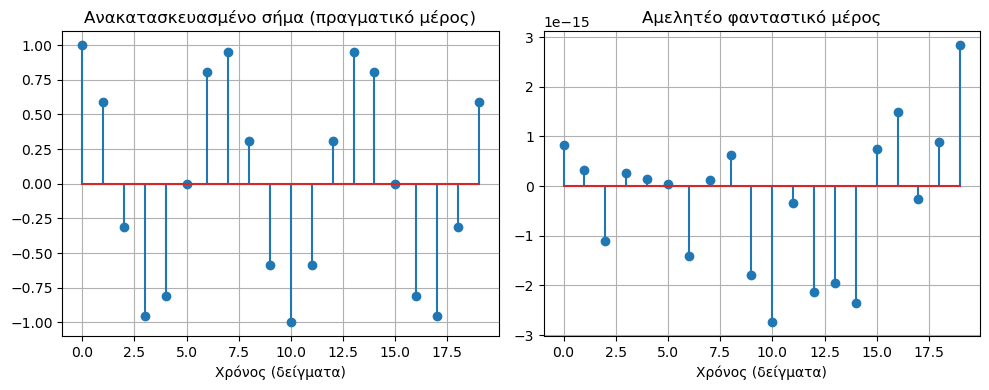

In [19]:
# Παράμετροι
N0 = 20                        # Περίοδος
k0 = 3
n = np.arange(N0)              # Διάνυσμα χρόνου 0..N-1
a = myDTFS(np.cos(2*np.pi*k0*n/N0))   # Συντελεστές του cos(2π k0 n / N)

xsynth = np.zeros(N0, dtype=np.complex128)   # κενό σήμα στο πεδίο του χρόνου

# Βρόχος - Άθροιση της εξίσωσης σύνθεσης για όλες τις αρμονικές k
for k in range(N0):
    xsynth += a[k] * np.exp(1j * (2*np.pi/N0) * k * n)

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(n, np.real(xsynth))
plt.grid()
plt.title('Ανακατασκευασμένο σήμα (πραγματικό μέρος)')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
plt.stem(n, np.imag(xsynth))
plt.grid()
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

Καλείστε να συμπληρώσετε τη δοσμένη συνάρτηση ````myiDTFS```` η οποία υπολογίζει την αντίστροφη σειρά Fourier διακριτού χρόνου (τη σύνθεση), την οποία θα χρησιμοποιήσετε παρακάτω.

In [20]:
def myiDTFS(a):
    """
    Ανακατασκευάζει μία περίοδο ενός περιοδικού σήματος διακριτού χρόνου
    από τους συντελεστές της σειράς Fourier του (σύνθεση).

    Ορίσματα:
        a : 1D μιγαδικός πίνακας μήκους N0 (οι συντελεστές a_k, k=0..N0-1)

    Επιστρέφει:
        x : 1D μιγαδικό np.ndarray μήκους N0 (μία περίοδος του σήματος x[n])
    """
    a = np.asarray(a, dtype=np.complex128)
    N0 = len(a)                 # Περίοδος = πλήθος συντελεστών

    n = np.arange(N0)           # Δείκτες χρόνου: 0..N0-1
    k = np.arange(N0)           # Δείκτες αρμονικών: 0..N0-1

    # Πίνακας Einv: διάσταση (N0, N0), με Einv[k, n] = exp(+j (2π/N0) k n)
    Einv = np.exp(1j * (2*np.pi/N0) * np.outer(k, n))

    # Σήμα στον χρόνο - χρήση των a και Einv
    x = a @ Einv               # Χρήση του τελεστή @

    return x

με $a$ το διάνυσμα των συντελεστών της σειράς Fourier. Το διάνυσμα $x$ θα περιέχει μία περίοδο του σήματος διακριτού χρόνου $x[n]$.

### Επεξήγηση:

Η παραπάνω υλοποίησή της γίνεται πιο γρήγορα και αποδοτικά ξανά με χρήση πινάκων, όπως προηγουμένως. Αυτή τη φορά, προσέξτε ότι το σήμα $x$ μπορεί να γραφεί ως το γινόμενο

\begin{equation}
x = a^T E_{inv}
\end{equation}

των πινάκων

\begin{equation}
a_{N_0\times 1} = \begin{bmatrix}
a_0 \\
a_1 \\
\vdots \\
a_{N_0-1}
\end{bmatrix}
\end{equation}

που περιέχει τους $N$ συντελεστές της σειράς Fourier και

\begin{equation}
E_{{inv}_{N_0 \times N_0}} = \begin{bmatrix}
\rule[.5ex]{2.5ex}{0.5pt}\  & e^{j\frac{2\pi}{N_0}\cdot 0 \cdot n} & \rule[.5ex]{2.5ex}{0.5pt}\  \\
\rule[.5ex]{2.5ex}{0.5pt}\  & e^{j\frac{2\pi}{N_0}\cdot 1 \cdot n} & \rule[.5ex]{2.5ex}{0.5pt}\  \\
 & \vdots & \\
\rule[.5ex]{2.5ex}{0.5pt}\  & e^{j\frac{2\pi}{N_0}(N_0-1) n} & \rule[.5ex]{2.5ex}{0.5pt}\  \\
\end{bmatrix}
\end{equation}

τον περίφημο πίνακα αντίστροφου Fourier, με $n = 0, 1, \cdots, N_0-1$.

Παρατηρήστε ότι σε κάθε γραμμή $k$ του πίνακα $E_{inv}$ υπάρχει ένα μιγαδικό εκθετικό σήμα $\textit{συγκεκριμένης}$ αρμονικής συχνότητας $\frac{2\pi}{N_0}k$, για τις χρονικές τιμές $n = 0,\cdots,N_0-1$. Έτσι, θα έχουμε $N_0$ γραμμές, όσες και οι αρμονικές (δηλ. οι συντελεστές). Επίσης, θα έχουμε $N_0$ στήλες, αφού η μεταβλητή $n$ δηλώνει τον χρόνο και έχουμε $N_0$ τέτοιες τιμές. Τέλος, παρατηρήστε ότι το γινόμενο $a^T E_{inv}$ θα πρέπει να σας δώσει ένα (θεωρητικά, πραγματικό αν το σήμα ήταν πραγματικό) διάνυσμα διάστασης $1\times N_0$. Κάθε τιμή του θα είναι η τιμή του σήματος $x[n]$ σε μία περίοδο!

---

Όταν γράψετε σωστά τη συνάρτηση, εκτελέστε τον παρακάτω κώδικα για να την ελέγξετε. Ο κώδικας ανακατασκευάζει το σήμα $x[n] = \cos\left(\frac{2\pi k_0}{N}n\right)$ από τους συντελεστές του, τους οποίους υπολογίζουμε με την ````myDTFS````.

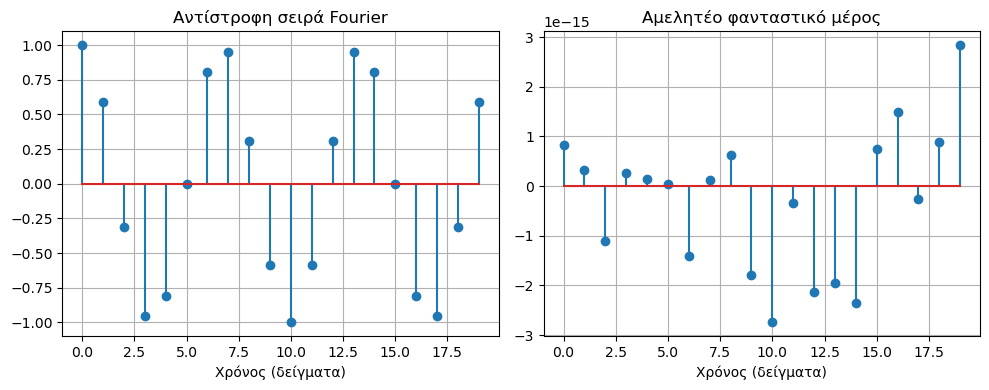

In [21]:
# Έλεγχος της myiDTFS...
N0 = 20                        # Περίοδος
k0 = 3
n = np.arange(N0)              # Διάνυσμα χρόνου 0..N-1
a = myDTFS(np.cos(2*np.pi*k0*n/N0))   # Συντελεστές του σήματος

x = myiDTFS(a)                # Κλήση της αντίστροφης σειράς Fourier

# Σχεδίαση αποτελεσμάτων
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.stem(n, np.real(x))
plt.grid()
plt.title('Αντίστροφη σειρά Fourier')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x))
plt.grid()
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

Αν όλα πάνε καλά, θα ανακτήσετε πιστά το αρχικό συνημίτονο, ενώ - παρ' όλο που το σήμα μας είναι πραγματικό - λόγω μικρών αριθμητικών σφαλμάτων θα υπάρχει κι ένα φανταστικό μέρος, το οποίο φυσικά είναι αμελητέο (της τάξης του $10^{-16}$).

---

$\textbf{Ως εδώ λοιπόν}$, απλά πρέπει να βεβαιωθείτε ότι οι δυο συναρτήσεις ````myDTFS, myiDTFS```` δουλεύουν σωστά, συμπληρώνοντας τις δυο γραμμές που λείπουν (μια γραμμή σε κάθε αρχείο) και εκτελώντας τον κώδικα ελέγχου για την καθεμιά.

## Ζητούμενα:

α. Γράψτε παρακάτω κώδικα ````Python```` που υπολογίζει και σχεδιάζει (με ````stem````) το πλάτος και τη φάση των συντελεστών της σειράς Fourier για τα παρακάτω περιοδικά σήματα

1. $x[n] = 1 + \sin\left(\frac{2\pi}{N}n\right) + 3\cos\left(\frac{2\pi}{N}n\right) + \cos\left(\frac{4\pi}{N}n + \frac{\pi}{2}\right)$, με περίοδο $N = 6$

2. ο περιοδικός τετραγωνικός παλμός με περίοδο $N = 16$, που σε μία περίοδο ισούται με $1$ για $0 \leq n \leq 4$ και $0$ αλλού

3. η περιοδική κρουστική σειρά $x[n] = \sum_{r=-\infty}^{+\infty}\delta[n-rN]$ με περίοδο $N = 12$ (δηλ. σε μία περίοδο, $1$ στο $n=0$ και $0$ αλλού)

με χρήση της συνάρτησης ````myDTFS````.

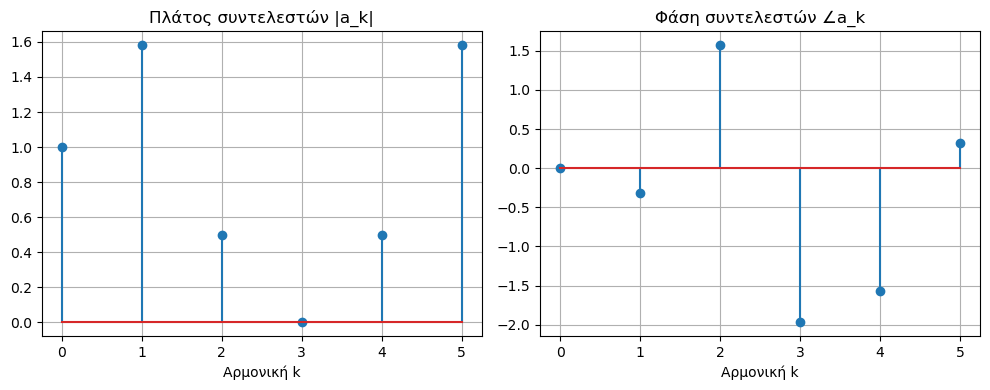

In [ ]:
# ΕΙΣΑΓΩΓΗ ΚΩΔΙΚΑ ΕΔΩ

# Χρήση της myDTFS

# 1.
N = 6                         # Περίοδος
n = np.arange(N)              # Διάνυσμα χρόνου 0..N-1
x = 1 + np.sin(2*np.pi*n/N) + 3*np.cos(2*np.pi*n/N) + np.cos(4*np.pi*n/N + np.pi/2)

a = myDTFS(x)                 # Κλήση της συνάρτησης

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(np.arange(N), np.abs(a))
plt.grid(True)
plt.title('Πλάτος συντελεστών |a_k|')
plt.xlabel('Αρμονική k')

plt.subplot(1, 2, 2)
plt.stem(np.arange(N), np.angle(a))
plt.grid(True)
plt.title('Φάση συντελεστών ∠a_k')
plt.xlabel('Αρμονική k')

plt.tight_layout()

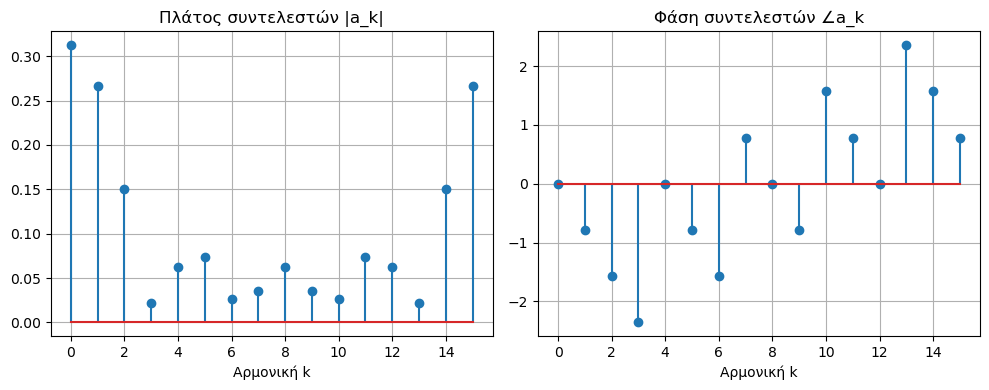

In [ ]:
# 2.
N = 16                        # Περίοδος
L = 5                         # Πλάτος του παλμού (n = 0..4)
n = np.arange(N)              # Διάνυσμα χρόνου 0..N-1
x = np.where(n < L, 1.0, 0.0) # Τετραγωνικός παλμός σε μία περίοδο

a = myDTFS(x)                 # Κλήση της συνάρτησης

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(np.arange(N), np.abs(a))
plt.grid(True)
plt.title('Πλάτος συντελεστών |a_k|')
plt.xlabel('Αρμονική k')

plt.subplot(1, 2, 2)
plt.stem(np.arange(N), np.angle(a))
plt.grid(True)
plt.title('Φάση συντελεστών ∠a_k')
plt.xlabel('Αρμονική k')

plt.tight_layout()

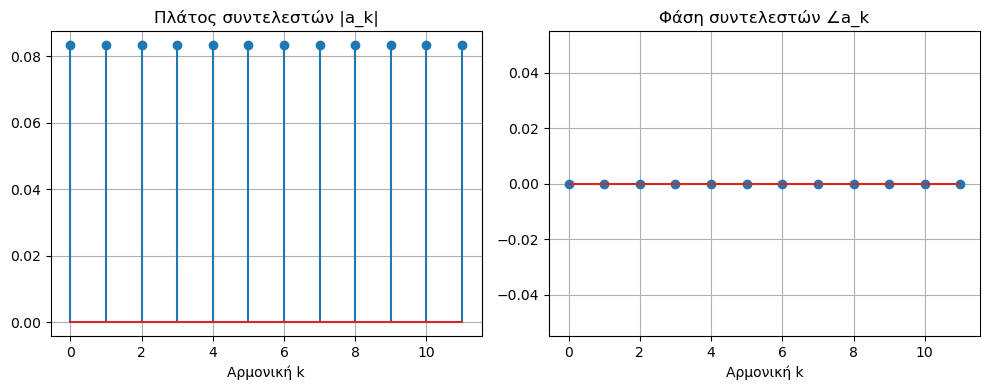

In [ ]:
# 3.
N = 12                        # Περίοδος
n = np.arange(N)              # Διάνυσμα χρόνου 0..N-1
x = np.zeros(N)               # Περιοδική κρουστική σειρά
x[0] = 1                      # 1 στο n = 0 (μία περίοδος)

a = myDTFS(x)                 # Κλήση της συνάρτησης

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(np.arange(N), np.abs(a))
plt.grid(True)
plt.title('Πλάτος συντελεστών |a_k|')
plt.xlabel('Αρμονική k')

plt.subplot(1, 2, 2)
plt.stem(np.arange(N), np.angle(a))
plt.grid(True)
plt.title('Φάση συντελεστών ∠a_k')
plt.xlabel('Αρμονική k')

plt.tight_layout()

Αν όλα πάνε καλά, θα παρατηρήσετε ότι: για το $(1)$ οι μόνοι μη μηδενικοί συντελεστές είναι στις αρμονικές $k = 0, 1, 2$ (και τις συζυγείς τους $k = 5, 4$), αφού το σήμα είναι άθροισμα λίγων μόνο ημιτόνων/συνημιτόνων. Για το $(2)$ το πλάτος των συντελεστών ακολουθεί το γνωστό σχήμα $\textit{τύπου Dirichlet}$ (πυρήνας Dirichlet). Για το $(3)$, όλοι οι συντελεστές είναι $\textit{σταθεροί}$ και ίσοι με $\frac{1}{N}$ - η περιοδική κρουστική σειρά έχει επίπεδο φάσμα, όπως ξέρετε από τη θεωρία.

---

β. Έστω οι συντελεστές σειράς Fourier των παρακάτω σημάτων

1. Του σήματος του ερωτήματος α.1 (περίοδος $N = 6$): $a_0 = 1,\ a_1 = \frac{3}{2} - \frac{1}{2}j,\ a_2 = \frac{1}{2}j,\ a_3 = 0,\ a_4 = -\frac{1}{2}j,\ a_5 = \frac{3}{2} + \frac{1}{2}j$

2. Του τετραγωνικού παλμού του ερωτήματος α.2 (περίοδος $N = 16$, πλάτος $L = 5$), με $a_0 = \frac{L}{N}$ και $\displaystyle a_k = \frac{1}{N}\,\frac{\sin\!\left(\frac{\pi k L}{N}\right)}{\sin\!\left(\frac{\pi k}{N}\right)}\,e^{-j\frac{\pi k (L-1)}{N}}$ για $k \neq 0$

3. Της περιοδικής κρουστικής σειράς του ερωτήματος α.3 (περίοδος $N = 12$): $a_k = \frac{1}{N}$ για κάθε $k$

Γράψτε κώδικα ````Python```` που ανακατασκευάζει και σχεδιάζει (με ````stem````) το σήμα στον χρόνο (πραγματικό και σχεδόν μηδενικό φανταστικό μέρος) από τους παραπάνω συντελεστές, με χρήση της συνάρτησης ````myiDTFS````.

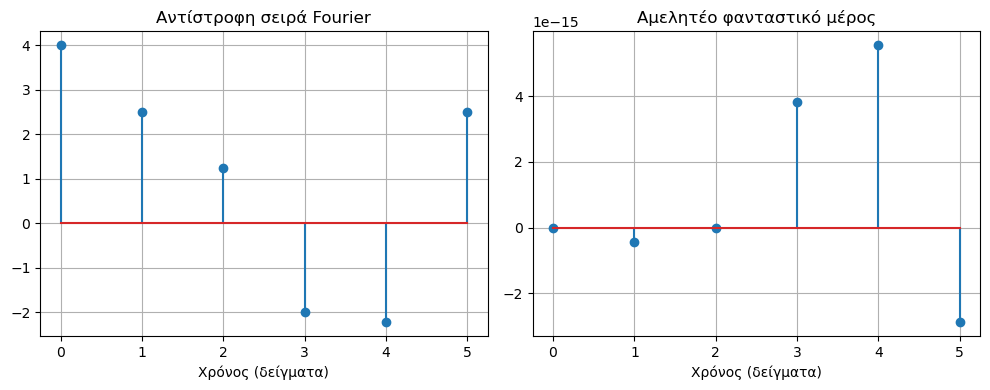

In [ ]:
# ΕΙΣΑΓΩΓΗ ΚΩΔΙΚΑ ΕΔΩ

# Χρήση της myiDTFS

# 1.
N = 6                                             # Περίοδος
a = np.array([1, 1.5-0.5j, 0.5j, 0, -0.5j, 1.5+0.5j])   # Συντελεστές a_0..a_5

x = myiDTFS(a)                                    # Κλήση της αντίστροφης σειράς
n = np.arange(N)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφη σειρά Fourier')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

C:\Users\kafge\AppData\Local\Temp\ipykernel_16800\2606120642.py:7: RuntimeWarning: invalid value encountered in true_divide
  a = (1/N) * np.sin(np.pi*k*L/N) / np.sin(np.pi*k/N) * np.exp(-1j*np.pi*k*(L-1)/N)


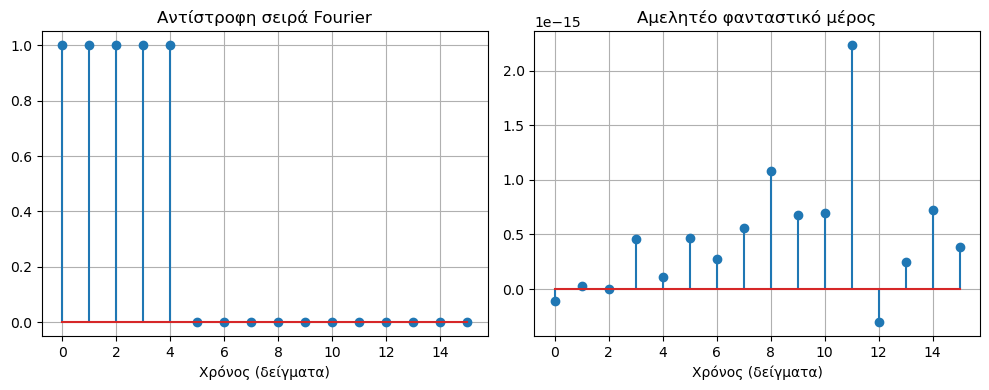

In [ ]:
# 2.
N = 16                        # Περίοδος
L = 5                         # Πλάτος του παλμού
k = np.arange(N).astype(float)

# Συντελεστές από τον κλειστό τύπο (πυρήνας Dirichlet)
a = (1/N) * np.sin(np.pi*k*L/N) / np.sin(np.pi*k/N) * np.exp(-1j*np.pi*k*(L-1)/N)
a[0] = L/N                    # Το όριο για k = 0

x = myiDTFS(a)                # Κλήση της αντίστροφης σειράς
n = np.arange(N)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφη σειρά Fourier')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

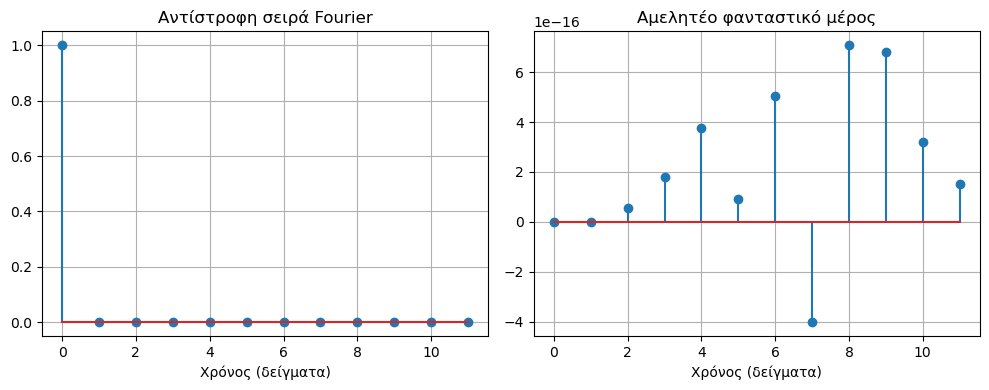

In [ ]:
# 3.
N = 12                        # Περίοδος
a = (1/N) * np.ones(N)        # Σταθεροί συντελεστές a_k = 1/N

x = myiDTFS(a)                # Κλήση της αντίστροφης σειράς
n = np.arange(N)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.stem(n, np.real(x))
plt.grid(True)
plt.title('Αντίστροφη σειρά Fourier')
plt.xlabel('Χρόνος (δείγματα)')

plt.subplot(1, 2, 2)
plt.stem(n, np.imag(x))
plt.grid(True)
plt.title('Αμελητέο φανταστικό μέρος')
plt.xlabel('Χρόνος (δείγματα)')

plt.tight_layout()

Αν όλα πάνε καλά, θα ανακτήσετε πιστά τα αρχικά σήματα του ερωτήματος α: το πολυτονικό σήμα του $(1)$, τον τετραγωνικό παλμό του $(2)$, και τη μοναδιαία κρουστική στο $n=0$ του $(3)$ - επιβεβαιώνοντας ότι οι ````myDTFS```` και ````myiDTFS```` είναι πράγματι αντίστροφες πράξεις.

----
----